In [ ]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util

In [ ]:
#Возьмем для тестирования мл-вакансию, мл-стэк и фронтенд-стэк
#Результатом нашего теста будет демонстрация, что распределения скоров 30 случаных набора скилов из мл-пула, лежит выше, чем распределение скоров из фронтенд пула

desc = 'ООО «Вычислительные решения» — российская компания, разрабатывающая высокотехнологичные аппаратно-программные и программные решения с 2014 года. В штате компании высококвалифицированные специалисты с большим опытом практической работы в области информационных технологий и информационной безопасности. На данный момент мы в поисках коллеги - Python-разработчика/ ML-инженера. Чем предстоит заниматься: разработка и поддержка ML-пайплайнов для обработки текстовых, графических и речевых данных; участие в исследовательских задачах в области AI/ML: от прототипирования до внедрения решений; контейнеризация приложений с помощью Docker: написание Dockerfile, сборка образов, запуск и отладка контейнеров; взаимодействие с сервисами через REST API; разработка и тестирование кода на Python в рамках ML- и ETL-процессов; настройка и самостоятельное разворачивание рабочего окружения под задачи разработки и тестирования; интеграция и настройка современных ML-моделей (включая LLM и NLP-решения); написание тестов (unit, integration) и ведение технической документации. Что мы ожидаем от кандидата: наличие желания участвовать в решении исследовательских задач в области AI/ML; хорошее знание языка Python (знание базовых алгоритмов и структур данных языка); знание алгоритмов машинного обучения, принципов функционирования нейросетей, их современных архитектур; опыт разработки приложений AI/ML на Python для текстовых/графических/речевых данных; знакомство с современными фреймворками для обработки данных с использованием AI (Pytorch, Tensorflow, LangChain, Transformers и т.п.); навыки контейнеризации приложений использованием Docker; опыт работы с системой контроля версий git; навыки тестирования разработанного решения; готовность документировать разработанное решение. Будет плюсом: будет плюсом опыт разработки RAG-систем, опыт продуктового развертывания систем на базе AI; будет плюсом опыт создания своих моделей для генеративного AI, тонкой настройки существующих. Что мы готовы предложить: график работы 5/2 с 9:00 до 18:00 в комфортабельном офисе в 10 мин. от станции м. Южная ; конкурентоспособный уровень дохода (исходя из компетенций кандидата); оформление по ТК РФ с первого дня; ДМС после испытательного срока; предоставляем корпоративное оборудование; возможность обучения и повышения квалификации; рост и развитие внутри компании. Командная работа занимает центральное место в нашей культуре. Мы верим, что успех достигается совместными усилиями, поэтому поддерживаем сплоченность команды и доверие между сотрудниками.'
req = ["Python","ML","Numpy","Pandas","Transformers"]
hh = ", ".join(req)

pool_ml = ["Java", "Python", "Scala", "Docker", "SQL", "Spark", "Hadoop", "TensorFlow", "PyTorch",
      "Архитектура ПО", "HighLoad", "Распределенные системы", "gRPC",
      "RabbitMQ", "Kafka", "Redis", "MongoDB", "Cassandra"]

pool_fe = ["HTML", "CSS", "JavaScript", "React", "Vue", "Angular",
      "TypeScript", "Webpack", "SASS", "LESS", "Bootstrap", "jQuery",
      "Figma", "Sketch", "Photoshop", "Illustrator", "UI/UX",
      "Адаптивная верстка", "Кроссбраузерность", "БЭМ", "Pixel Perfect"]

In [ ]:
model = SentenceTransformer('Nashhz/SBERT_KFOLD_Job_Descriptions_to_Skills')

e_desc = model.encode(desc)
e_hh = model.encode(hh)

rel = []
for _ in range(30):
    k = np.random.randint(5, 9)
    samp = list(np.random.choice(pool_ml, size=k, replace=False))
    samp = samp + list(np.random.choice(req, size=2, replace=False))
    g = ", ".join(samp)
    e_g = model.encode(g)
    sd = util.cos_sim(e_desc, e_g).item()
    ss = util.cos_sim(e_hh, e_g).item()
    rel.append(0.5 * sd + 0.5 * ss)

irr = []
for _ in range(30):
    k = np.random.randint(5, 9)
    samp = list(np.random.choice(pool_fe, size=k, replace=False))
    g = ", ".join(samp)
    e_g = model.encode(g)
    sd = util.cos_sim(e_desc, e_g).item()
    ss = util.cos_sim(e_hh, e_g).item()
    irr.append(0.5 * sd + 0.5 * ss)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

/tmp/ipykernel_16234/2646260983.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot([rel, irr], labels=['ML', 'FE'])


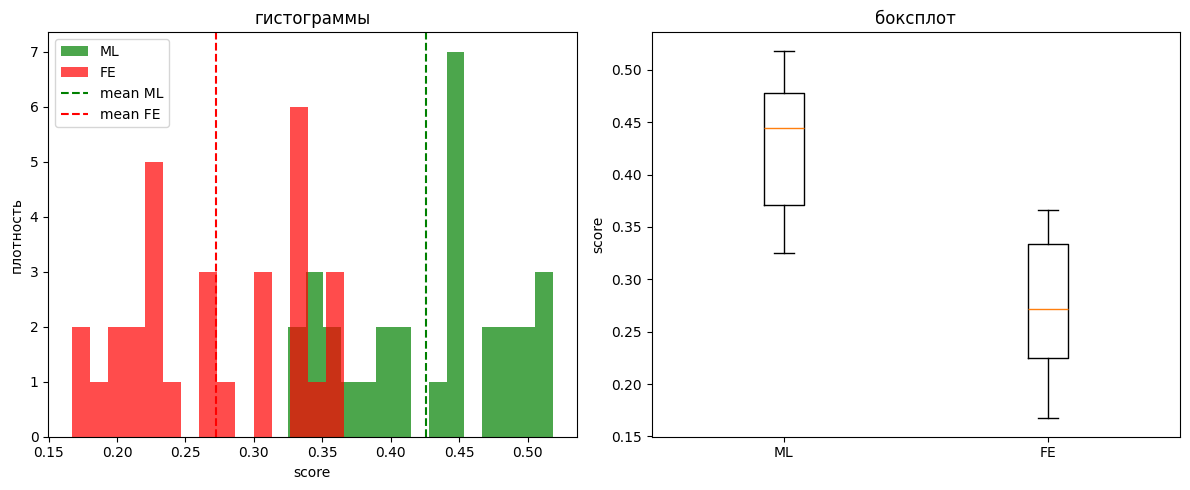

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(rel, bins=15, label='ML', color='green')
plt.hist(irr, bins=15, label='FE', color='red')
plt.axvline(np.mean(rel), color='green', linestyle='--', label='среднее ML')
plt.axvline(np.mean(irr), color='red', linestyle='--', label='среднее FE')
plt.xlabel('score')
plt.ylabel('плотность')
plt.title('гистограммы')
plt.legend()

plt.subplot(1, 2, 2)
bp = plt.boxplot([rel, irr], labels=['ML', 'FE'])
plt.ylabel('score')
plt.title('боксплот')
plt.tight_layout()
plt.show()